In [22]:
# Import pandas for data loading and manipulation
import pandas as pd

# Import matplotlib for building charts
import matplotlib.pyplot as plt

# Import ticker for formatting numbers on chart axes
import matplotlib.ticker as ticker

# Import seaborn for professional chart styling
import seaborn as sns

print("All libraries loaded successfully")


All libraries loaded successfully


In [23]:
df_peek = pd.read_csv('energy_certificates.csv', nrows=5, low_memory=False)
print(df_peek.columns.tolist())

['certificate_number', 'address1', 'address2', 'address3', 'address', 'postcode', 'inspection_date', 'uprn', 'environment_impact_potential', 'energy_consumption_current', 'energy_consumption_potential', 'environment_impact_current', 'co2_emissions_current', 'co2_emiss_curr_per_floor_area', 'co2_emissions_potential', 'total_floor_area', 'lodgement_date', 'report_type', 'posttown', 'lodgement_datetime', 'current_energy_efficiency', 'current_energy_rating', 'potential_energy_efficiency', 'potential_energy_rating', 'extension_count', 'number_open_fireplaces', 'number_heated_rooms', 'number_habitable_rooms', 'low_energy_lighting', 'low_energy_fixed_lighting_outlets_count', 'solar_water_heating_flag', 'mechanical_ventilation', 'tenure', 'property_type', 'transaction_type', 'construction_age_band', 'built_form', 'energy_tariff', 'glazed_type', 'glazed_area', 'heat_loss_corridor', 'main_fuel', 'unheated_corridor_length', 'floor_level', 'flat_top_storey', 'flat_storey_count', 'mains_gas_flag', 

In [24]:
import os
print(os.getcwd())

f:\Python\Jupiter_Python\EPC_project


In [25]:
import os
file_size = os.path.getsize('energy_certificates.csv')
print(f"File size: {file_size} bytes")


File size: 677103190 bytes


In [26]:
# Load the dataset in chunks to avoid memory issues
# chunksize reads 50000 rows at a time instead of all at once
chunks = []
for chunk in pd.read_csv('energy_certificates.csv',
                         low_memory=False,
                         chunksize=50000,
                         usecols=[
                             'current_energy_rating',
                             'potential_energy_rating',
                             'potential_energy_efficiency',
                             'current_energy_efficiency',
                             'property_type',
                             'construction_age_band',
                             'total_floor_area',
                             'local_authority_label'
                         ]):
    chunks.append(chunk)

# Combine all chunks into one dataframe
df = pd.concat(chunks, ignore_index=True)
print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")
df.head()

Rows: 637773
Columns: 8


,total_floor_area,current_energy_efficiency,current_energy_rating,potential_energy_efficiency,potential_energy_rating,property_type,construction_age_band,local_authority_label
0,48,75,C,75,C,Flat,England and Wales: 2012-2021,Lewisham
1,79,70,C,80,C,House,England and Wales: 1930-1949,Lewisham
2,57,70,C,70,C,Flat,England and Wales: 1991-1995,Greenwich
3,63,73,C,79,C,Maisonette,England and Wales: 1967-1975,Southwark
4,64,77,C,80,C,Flat,England and Wales: 1976-1982,Southwark


In [27]:
import os
print(os.path.getsize('energy_certificates.csv'), "bytes")

677103190 bytes


In [28]:
def clean_epc_data(dataframe): #clean up function to get rid of duplicates as houses can let and sold many times so it repeats addresses
    
    df_clean = dataframe.copy()
    
    # Drop rows where energy rating is missing
    df_clean = df_clean.dropna(subset=['current_energy_rating', 'potential_energy_rating'])
    
    # Convert floor area to numeric
    df_clean['total_floor_area'] = pd.to_numeric(df_clean['total_floor_area'], errors='coerce')
    
    # Drop duplicates
    before = len(df_clean)
    df_clean = df_clean.drop_duplicates()
    after = len(df_clean)
    
    print(f"Rows before cleaning: {before}")
    print(f"Duplicate rows removed: {before - after}")
    print(f"Final clean rows: {after}")
    print(f"Missing floor area values: {df_clean['total_floor_area'].isnull().sum()}")
    
    return df_clean


df_clean = clean_epc_data(df)

Rows before cleaning: 637773
Duplicate rows removed: 188761
Final clean rows: 449012
Missing floor area values: 0


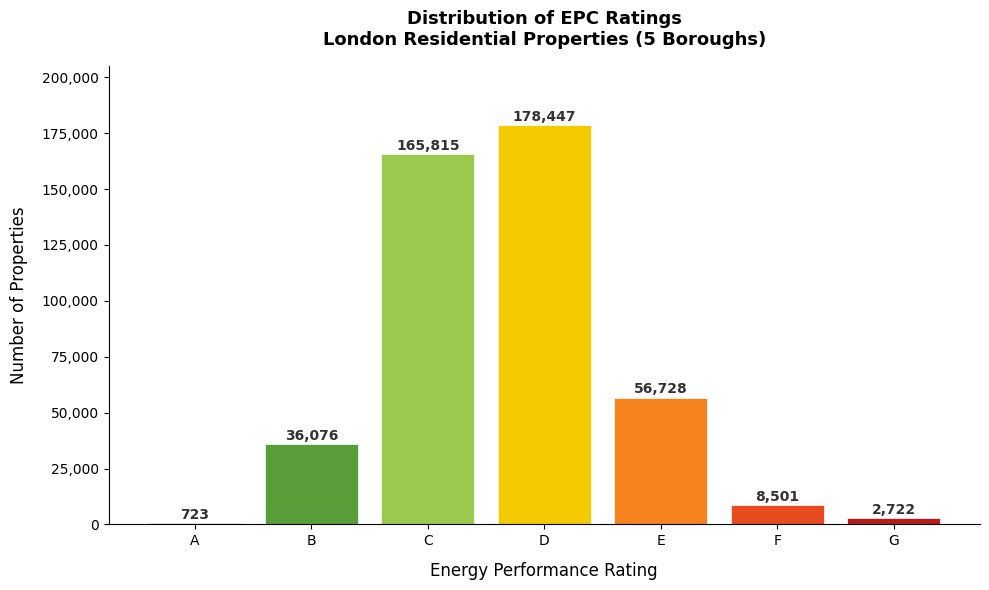

Chart saved


In [29]:
# Count properties at each rating and sort A to G
rating_counts = df_clean['current_energy_rating'].value_counts() #counts how many properties are at each rating
rating_counts = rating_counts.reindex(['A', 'B', 'C', 'D', 'E', 'F', 'G']) #sorts them out in the correct order

# Colours green to red matching the real EPC colour scheme
colours = ['#2d6a2d', '#5a9e3a', '#9bc94e', '#f5c900', '#f5841f', '#e84c1e', '#b81a1a'] #adds the color scheme for each rating

# Build the chart
fig, ax = plt.subplots(figsize=(10, 6)) #builds the empty chart 10x6

bars = ax.bar(rating_counts.index, rating_counts.values, color=colours, edgecolor='white', linewidth=0.5) # gives the labels from A to G for the x axis, gives the height of the bars (values), applies the colours, adds a thin white line to separate the bars

# Add count labels on top of each bar
for bar, count in zip(bars, rating_counts.values):  # loops through every bar and writes the number on top of it, it finds the horizontal centre of each bar and then + 500, and fromats the number with commas so 150000 becomes 150,000
    if not pd.isna(count):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 500,
            f'{int(count):,}',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold',
            color='#333333'
        )

# Labels and formatting
ax.set_xlabel('Energy Performance Rating', fontsize=12, labelpad=10)  #add the labels
ax.set_ylabel('Number of Properties', fontsize=12, labelpad=10)
ax.set_title('Distribution of EPC Ratings\nLondon Residential Properties (5 Boroughs)', 
             fontsize=13, fontweight='bold', pad=15)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))  # formats the numbers on the y axis with commas
ax.spines['top'].set_visible(False)  # removes the top and right border lines from the chart to clean them up
ax.spines['right'].set_visible(False)
ax.set_ylim(0, rating_counts.max() * 1.15)  # sets the height of the y axis at 15% more than the height of the tallest bar

plt.tight_layout()  #adjusts spacings so nothing overlaps
plt.savefig('chart1_energy_rating_distribution.png', dpi=150, bbox_inches='tight') #saves the chart as a PNG and sents the image quality
plt.show() #displays it 

print("Chart saved")

In [30]:
# Count property types 
type_counts = df_clean['property_type'].value_counts()

print("Property types in the dataset:")
print(type_counts)

Property types in the dataset:
property_type
Flat          242598
House         161372
Maisonette     37990
Bungalow        7039
Park home          5
Name: count, dtype: int64


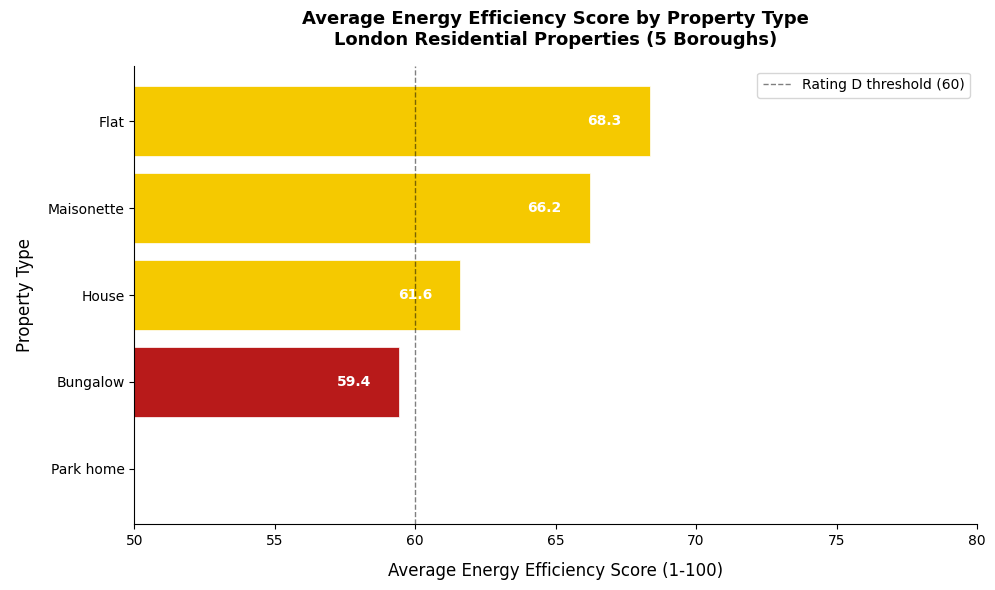

Chart 2 saved


In [31]:
type_avg = df_clean.groupby('property_type')['current_energy_efficiency'].mean().sort_values() #splits the data into 5 groups, one per property type and calc the average efficiency score for each group and then sorts them from lowest to highest

colours = ['#b81a1a' if x < 60 else '#f5c900' if x < 70 else '#5a9e3a' for x in type_avg.values] #colours

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(type_avg.index, type_avg.values, color=colours, edgecolor='white', linewidth=0.5) #barh means horizontal chart

for bar, value in zip(bars, type_avg.values):  #loops through every bar and writes the average score inside it near the right edge and formats it to one decimal place
    ax.text(
        value - 1,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.1f}',
        ha='right',
        va='center',
        fontsize=10,
        fontweight='bold',
        color='white'
    )

ax.axvline(x=60, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Rating D threshold (60)') #draws a vertial line at 60 which is the D and E boundary. Any property that does not reach the line operates at an E or lower
ax.set_xlim(50, 80)  #sets the x axis to start at 50
ax.set_xlabel('Average Energy Efficiency Score (1-100)', fontsize=12, labelpad=10)  #labels
ax.set_ylabel('Property Type', fontsize=12, labelpad=10)
ax.set_title('Average Energy Efficiency Score by Property Type\nLondon Residential Properties (5 Boroughs)', 
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart2_efficiency_by_property_type.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart 2 saved")

In [32]:
print(df_clean['construction_age_band'].value_counts().sort_index())


construction_age_band
1800      3
1840      2
1870      1
1890      1
1895      1
       ... 
H        97
I       179
J        77
K        45
L        22
Name: count, Length: 94, dtype: int64


In [33]:
print(df_clean['construction_age_band'].value_counts().head(20))


construction_age_band
England and Wales: 1900-1929       94315
England and Wales: 1930-1949       67700
England and Wales: 1950-1966       55789
England and Wales: before 1900     51259
England and Wales: 1967-1975       40712
England and Wales: 1983-1990       20574
England and Wales: 1976-1982       19244
England and Wales: 1996-2002       17673
England and Wales: 1991-1995       13909
England and Wales: 2003-2006       13536
England and Wales: 2007-2011        8008
England and Wales: 2012 onwards     4078
2016                                2746
England and Wales: 2007 onwards     2624
2014                                2562
2015                                2531
England and Wales: 2012-2021        2512
2013                                2510
2019                                2474
2018                                2204
Name: count, dtype: int64


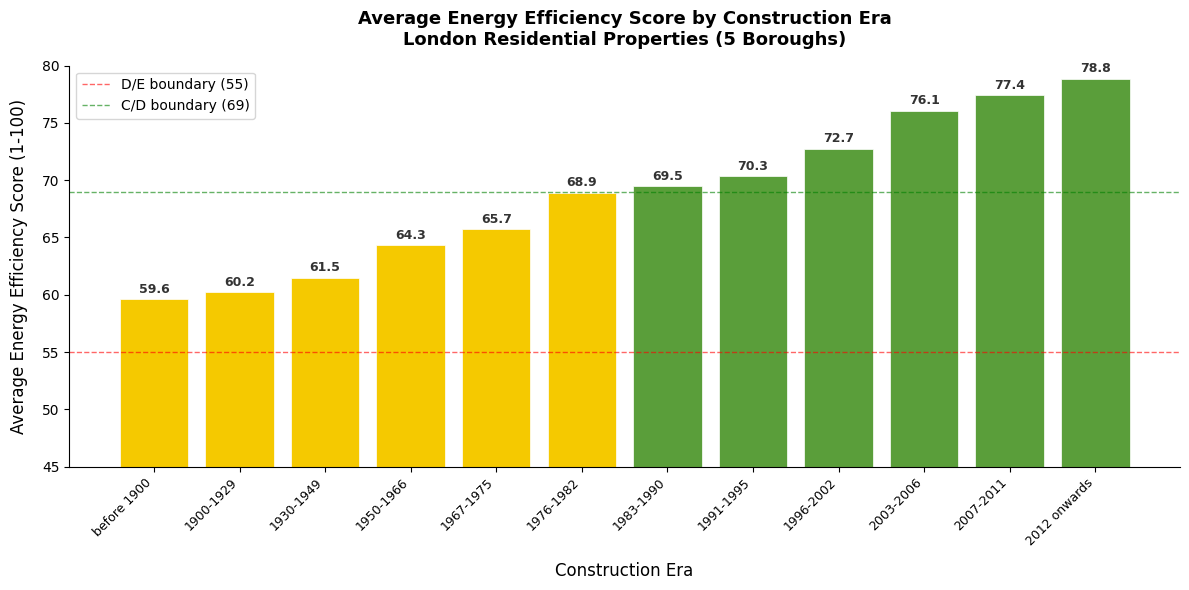

Chart 3 saved


In [34]:
# Filter to clean age band entries only
mask = df_clean['construction_age_band'].str.startswith('England and Wales', na=False)
df_age = df_clean[mask].copy()  # filters out all the messy rows and keeps the ones that start with england and wales

# Shorten the labels
df_age['age_label'] = df_age['construction_age_band'].str.replace('England and Wales: ', '').str.strip()  #shortwns the lables by removing the txt

# Calculate average efficiency per age band
age_avg = df_age.groupby('age_label')['current_energy_efficiency'].mean() # groups by age bend and calc the avg energy effieciency for each era

# Put in chronological order
age_order = ['before 1900', '1900-1929', '1930-1949', '1950-1966', 
             '1967-1975', '1976-1982', '1983-1990', '1991-1995',
             '1996-2002', '2003-2006', '2007-2011', '2012 onwards'] #puts the bands in chronological order
age_avg = age_avg.reindex(age_order)

# Assign colours based on correct EPC thresholds
colours = ['#b81a1a' if x < 55 else '#f5c900' if x < 69 else '#5a9e3a' #colours
           for x in age_avg.values]

# Build the chart
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(age_avg.index, age_avg.values, color=colours, edgecolor='white', linewidth=0.5)

# Add score labels on top of each bar
for bar, value in zip(bars, age_avg.values):
    if not pd.isna(value):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{value:.1f}',
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold',
            color='#333333'
        )

# Add threshold lines
ax.axhline(y=55, color='red', linestyle='--', linewidth=1, alpha=0.6, label='D/E boundary (55)')
ax.axhline(y=69, color='green', linestyle='--', linewidth=1, alpha=0.6, label='C/D boundary (69)')

# Formatting
ax.set_xlabel('Construction Era', fontsize=12, labelpad=10)
ax.set_ylabel('Average Energy Efficiency Score (1-100)', fontsize=12, labelpad=10)
ax.set_title('Average Energy Efficiency Score by Construction Era\nLondon Residential Properties (5 Boroughs)', 
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylim(45, 80)
plt.xticks(rotation=45, ha='right', fontsize=9)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart3_efficiency_by_construction_era.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart 3 saved")

In [35]:
df_clean['improvement_gap'] = df_clean['potential_energy_efficiency'] - df_clean['current_energy_efficiency']

print("Average improvement gap by property type:")
print(df_clean.groupby('property_type')['improvement_gap'].mean().sort_values(ascending=False).round(1))

print()
# Add improvement gap column to df_age
df_age['improvement_gap'] = df_age['potential_energy_efficiency'] - df_age['current_energy_efficiency']
print("Average improvement gap by construction era:")
print(df_age.groupby('age_label')['improvement_gap'].mean().reindex(age_order).round(1))

Average improvement gap by property type:
property_type
Bungalow      23.6
Park home     21.0
House         20.8
Maisonette     9.2
Flat           8.2
Name: improvement_gap, dtype: float64

Average improvement gap by construction era:
age_label
before 1900     17.6
1900-1929       17.3
1930-1949       17.3
1950-1966       13.0
1967-1975       11.9
1976-1982       11.2
1983-1990       10.6
1991-1995        9.8
1996-2002        7.8
2003-2006        5.5
2007-2011        3.5
2012 onwards     2.8
Name: improvement_gap, dtype: float64


In [36]:
df_age['improvement_gap'] = df_age['potential_energy_efficiency'] - df_age['current_energy_efficiency']

print("Average improvement gap by construction era:")
print(df_age.groupby('age_label')['improvement_gap'].mean().reindex(age_order).round(1))

Average improvement gap by construction era:
age_label
before 1900     17.6
1900-1929       17.3
1930-1949       17.3
1950-1966       13.0
1967-1975       11.9
1976-1982       11.2
1983-1990       10.6
1991-1995        9.8
1996-2002        7.8
2003-2006        5.5
2007-2011        3.5
2012 onwards     2.8
Name: improvement_gap, dtype: float64


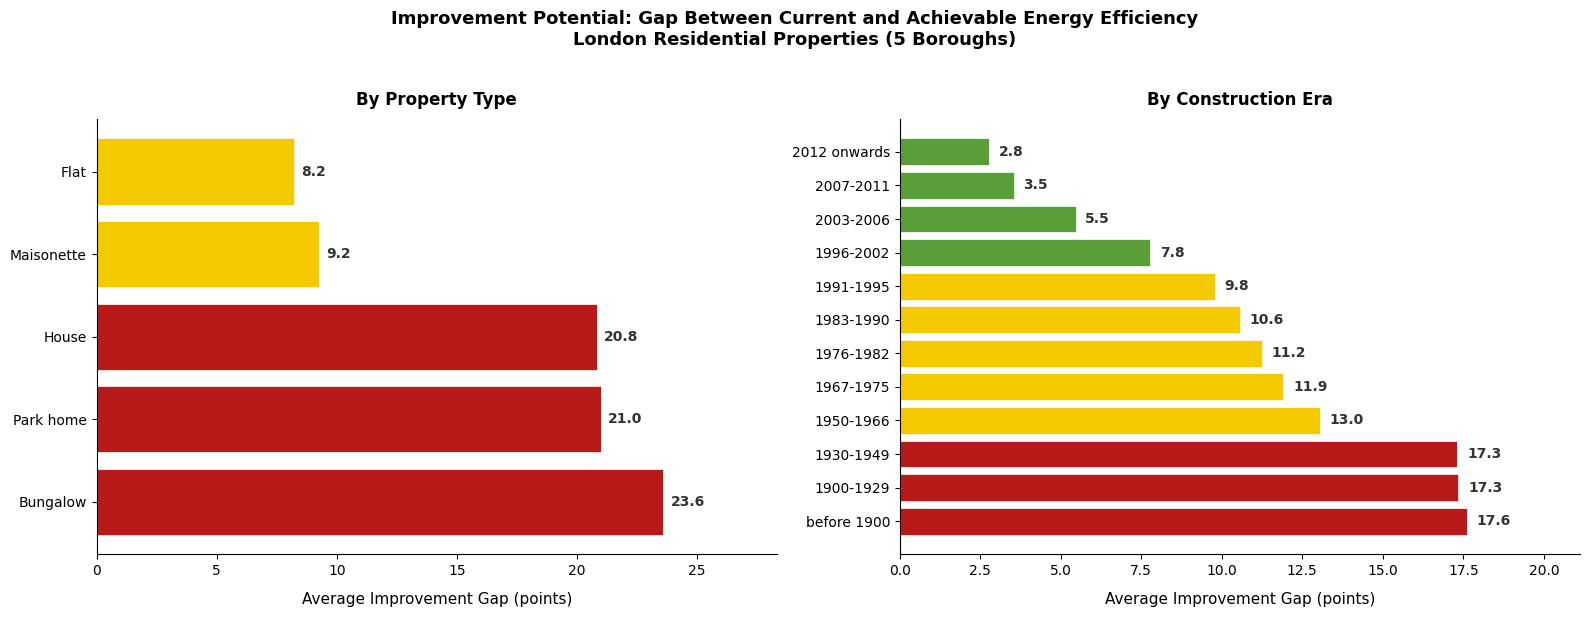

Chart 4 saved


In [37]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6)) #creates one figure with two charts side by side

# Left panel: gap by property type
type_gap = df_clean.groupby('property_type')['improvement_gap'].mean().sort_values(ascending=False) #calc the avg gap for each property type and sorts largest to smallest so the biggest opportunity appears at the top
colours_type = ['#b81a1a' if x > 15 else '#f5c900' if x > 8 else '#5a9e3a' for x in type_gap.values]  #colours

bars1 = ax1.barh(type_gap.index, type_gap.values, color=colours_type, edgecolor='white', linewidth=0.5) #horizontal bar chart on the left panel
for i, value in enumerate(type_gap.values): #writes the gap value to the right of each bar
    ax1.text(value + 0.3, i, f'{value:.1f}', va='center', fontsize=10, fontweight='bold', color='#333333') 

ax1.set_xlabel('Average Improvement Gap (points)', fontsize=11, labelpad=10)  #labels
ax1.set_title('By Property Type', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlim(0, type_gap.max() * 1.2)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Right panel: gap by construction era
age_gap = df_age.groupby('age_label')['improvement_gap'].mean().reindex(age_order)  
colours_age = ['#b81a1a' if x > 15 else '#f5c900' if x > 8 else '#5a9e3a' for x in age_gap.values]

bars2 = ax2.barh(age_gap.index, age_gap.values, color=colours_age, edgecolor='white', linewidth=0.5)
for i, value in enumerate(age_gap.values):
    if not pd.isna(value):
        ax2.text(value + 0.3, i, f'{value:.1f}', va='center', fontsize=10, fontweight='bold', color='#333333')

ax2.set_xlabel('Average Improvement Gap (points)', fontsize=11, labelpad=10)
ax2.set_title('By Construction Era', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlim(0, age_gap.max() * 1.2)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Overall title
fig.suptitle('Improvement Potential: Gap Between Current and Achievable Energy Efficiency\nLondon Residential Properties (5 Boroughs)', 
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('chart4_improvement_gap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart 4 saved")

In [38]:
import os
charts = ['chart1_energy_rating_distribution.png',
          'chart2_efficiency_by_property_type.png', 
          'chart3_efficiency_by_construction_era.png',
          'chart4_improvement_gap.png']

for chart in charts:
    size = os.path.getsize(chart)
    print(f"{chart}: {size:,} bytes")

chart1_energy_rating_distribution.png: 61,617 bytes
chart2_efficiency_by_property_type.png: 62,455 bytes
chart3_efficiency_by_construction_era.png: 93,902 bytes
chart4_improvement_gap.png: 105,494 bytes


Analysis: London Residential Energy Performance
Dataset Overview
This analysis examines 449,012 residential properties across five London boroughs, Lambeth, Southwark, Lewisham, Greenwich, and Croydon, using data from the UK Government's Energy Performance Certificate register. The dataset was cleaned from 637,773 raw records, removing 188,761 duplicate entries representing properties that had been reassessed multiple times over the years.
Finding 1: Most London Properties Are Rated C or D
Chart 1 reveals that the majority of London's housing stock is concentrated at ratings D and C, with 178,447 properties at D and 165,815 at C, together accounting for 76.6% of all properties in the dataset. Only 723 properties across five boroughs achieved an A rating, representing less than 0.2% of the total. This distribution is significant in the context of the UK government's Heat and Buildings Strategy, which sets a target for as many homes as possible to reach EPC band C by 2035, and for all fuel poor homes to reach a minimum of band C by 2030. The data shows that while a substantial proportion of properties have already reached C, a large number remain at D or below and will require targeted intervention to meet this ambition.
Finding 2: Bungalows Are the Worst Performing Property Type
Chart 2 demonstrates that bungalows are the worst performing property type with an average energy efficiency score of 59.4, falling below the D band threshold of 60. Flats perform significantly better at 68.3, which is consistent with building physics principles. Flats share walls, floors, and ceilings with neighbouring properties, reducing heat loss through the building envelope. Bungalows by contrast have a disproportionately large roof area relative to their floor space, making them particularly vulnerable to upward heat loss. This means loft insulation improvements would deliver a disproportionately large efficiency gain in bungalows compared to other property types.
Finding 3: Newer Buildings Perform Significantly Better
Chart 3 shows a clear and consistent improvement in energy performance with each successive construction era. Properties built before 1900 average just 59.6 while those built after 2012 average 78.8, a difference of 19.2 points. The most significant improvement occurs between the 1976 to 1982 and 1983 to 1990 bands, reflecting the introduction of meaningful thermal insulation requirements in UK building regulations following the 1970s energy crisis. This pattern confirms that regulatory intervention has a measurable and lasting impact on building performance, and that the oldest housing stock represents the greatest technical challenge for the retrofit programme.
Finding 4: Pre-1930 Bungalows Represent the Greatest Retrofit Opportunity
Chart 4 identifies bungalows as having the largest improvement gap of any property type at 23.6 points, meaning a typical bungalow could improve by nearly 24 efficiency points if all recommended measures were implemented. Properties built before 1930 show an average improvement gap of over 17 points. The combination of these two findings suggests that pre-1930 bungalows represent the single greatest retrofit opportunity in the dataset. Closing this gap through measures such as loft insulation, cavity wall insulation, and boiler upgrades would bring a significant number of properties up to or beyond the government's EPC C target, directly contributing to the UK's net zero ambitions and reducing energy bills for some of the most vulnerable households.
Recommendation
Local authorities and housing associations targeting the government's 2030 EPC C goal should prioritise pre-1930 bungalows and houses. This group combines poor current performance, large improvement potential, and significant volume, representing the highest return on retrofit investment across these five London boroughs. The findings align directly with the priorities set out in the UK Heat and Buildings Strategy, which commits £3.9 billion to building decarbonisation and specifically targets low income and fuel poor households living in the least efficient properties.

Analysis: London Residential Energy Performance
Dataset Overview
This analysis examines 449,012 residential properties across five London boroughs, Lambeth, Southwark, Lewisham, Greenwich, and Croydon, using data from the UK Government's Energy Performance Certificate register. The dataset was cleaned from 637,773 raw records, removing 188,761 duplicate entries representing properties that had been reassessed multiple times over the years.
Finding 1: Most London Properties Are Rated C or D
Chart 1 reveals that the majority of London's housing stock is concentrated at ratings D and C, with 178,447 properties at D and 165,815 at C, together accounting for 76.6% of all properties in the dataset. Only 723 properties across five boroughs achieved an A rating, representing less than 0.2% of the total. This distribution is significant in the context of the UK government's Heat and Buildings Strategy, which sets a target for as many homes as possible to reach EPC band C by 2035, and for all fuel poor homes to reach a minimum of band C by 2030. The data shows that while a substantial proportion of properties have already reached C, a large number remain at D or below and will require targeted intervention to meet this ambition.
Finding 2: Bungalows Are the Worst Performing Property Type
Chart 2 demonstrates that bungalows are the worst performing property type with an average energy efficiency score of 59.4, falling below the D band threshold of 60. Flats perform significantly better at 68.3, which is consistent with building physics principles. Flats share walls, floors, and ceilings with neighbouring properties, reducing heat loss through the building envelope. Bungalows by contrast have a disproportionately large roof area relative to their floor space, making them particularly vulnerable to upward heat loss. This means loft insulation improvements would deliver a disproportionately large efficiency gain in bungalows compared to other property types.
Finding 3: Newer Buildings Perform Significantly Better
Chart 3 shows a clear and consistent improvement in energy performance with each successive construction era. Properties built before 1900 average just 59.6 while those built after 2012 average 78.8, a difference of 19.2 points. The most significant improvement occurs between the 1976 to 1982 and 1983 to 1990 bands, reflecting the introduction of meaningful thermal insulation requirements in UK building regulations following the 1970s energy crisis. This pattern confirms that regulatory intervention has a measurable and lasting impact on building performance, and that the oldest housing stock represents the greatest technical challenge for the retrofit programme.
Finding 4: Pre-1930 Bungalows Represent the Greatest Retrofit Opportunity
Chart 4 identifies bungalows as having the largest improvement gap of any property type at 23.6 points, meaning a typical bungalow could improve by nearly 24 efficiency points if all recommended measures were implemented. Properties built before 1930 show an average improvement gap of over 17 points. The combination of these two findings suggests that pre-1930 bungalows represent the single greatest retrofit opportunity in the dataset. Closing this gap through measures such as loft insulation, cavity wall insulation, and boiler upgrades would bring a significant number of properties up to or beyond the government's EPC C target, directly contributing to the UK's net zero ambitions and reducing energy bills for some of the most vulnerable households.
Recommendation
Local authorities and housing associations targeting the government's 2030 EPC C goal should prioritise pre-1930 bungalows and houses. This group combines poor current performance, large improvement potential, and significant volume, representing the highest return on retrofit investment across these five London boroughs. The findings align directly with the priorities set out in the UK Heat and Buildings Strategy, which commits £3.9 billion to building decarbonisation and specifically targets low income and fuel poor households living in the least efficient properties.

## Analysis: London Residential Energy Performance

### Dataset Overview
This analysis examines 449,012 residential properties across five London boroughs: Lambeth, Southwark, Lewisham, Greenwich, and Croydon, using data from the UK Government's Energy Performance Certificate register. The dataset was cleaned from 637,773 raw records, removing 188,761 duplicate entries representing properties that had been reassessed multiple times over the years.

### Finding 1: Most London Properties Are Rated C or D
Chart 1 reveals that the majority of London's housing stock is concentrated at ratings D and C, with 178,447 properties at D and 165,815 at C, together accounting for 76.6% of all properties in the dataset. Only 723 properties across five boroughs achieved an A rating, representing less than 0.2% of the total. This distribution is significant in the context of the UK government's Heat and Buildings Strategy, which sets a target for as many homes as possible to reach EPC band C by 2035, and for all fuel poor homes to reach a minimum of band C by 2030. The data shows that while a substantial proportion of properties have already reached C, a large number remain at D or below and will require targeted intervention to meet this ambition.

### Finding 2: Bungalows Are the Worst Performing Property Type
Chart 2 demonstrates that bungalows are the worst performing property type with an average energy efficiency score of 59.4, falling below the D band threshold of 60. Flats perform significantly better at 68.3, which is consistent with building physics principles. Flats share walls, floors, and ceilings with neighbouring properties, reducing heat loss through the building envelope. Bungalows by contrast have a disproportionately large roof area relative to their floor space, making them particularly vulnerable to upward heat loss. This means loft insulation improvements would deliver a disproportionately large efficiency gain in bungalows compared to other property types.

### Finding 3: Newer Buildings Perform Significantly Better
Chart 3 shows a clear and consistent improvement in energy performance with each successive construction era. Properties built before 1900 average just 59.6 while those built after 2012 average 78.8, a difference of 19.2 points. The most significant improvement occurs between the 1976 to 1982 and 1983 to 1990 bands, reflecting the introduction of meaningful thermal insulation requirements in UK building regulations following the 1970s energy crisis. This pattern confirms that regulatory intervention has a measurable and lasting impact on building performance, and that the oldest housing stock represents the greatest technical challenge for the retrofit programme.

### Finding 4: Pre-1930 Bungalows Represent the Greatest Retrofit Opportunity
Chart 4 identifies bungalows as having the largest improvement gap of any property type at 23.6 points, meaning a typical bungalow could improve by nearly 24 efficiency points if all recommended measures were implemented. Properties built before 1930 show an average improvement gap of over 17 points. The combination of these two findings suggests that pre-1930 bungalows represent the single greatest retrofit opportunity in the dataset. Closing this gap through measures such as loft insulation, cavity wall insulation, and boiler upgrades would bring a significant number of properties up to or beyond the government's EPC C target, directly contributing to the UK's net zero ambitions and reducing energy bills for some of the most vulnerable households.

### Recommendation
Local authorities and housing associations targeting the government's 2030 EPC C goal should prioritise pre-1930 bungalows and houses. This group combines poor current performance, large improvement potential, and significant volume, representing the highest return on retrofit investment across these five London boroughs. The findings align directly with the priorities set out in the UK Heat and Buildings Strategy, which commits £3.9 billion to building decarbonisation and specifically targets low income and fuel poor households living in the least efficient properties.